# 🐶🐱 **Classificador de Cães e Gatos — CNN do Zero**

> **Objetivo:** Construir um classificador binário de imagens (cão vs gato) **sem modelos pré-treinados**, utilizando PyTorch e aplicando boas práticas de engenharia de Machine Learning.

---

## 📋 Visão Geral do Pipeline

```text
1. Configuração do Ambiente
2. Acesso e Verificação dos Dados
3. Limpeza e Análise Exploratória (EDA)
4. Data Augmentation e Pré-processamento
5. Carregamento dos Dados
6. Construção da CNN Residual
7. Treinamento e Validação
8. Avaliação no Conjunto de Teste
9. Inferência em Imagens Novas
10. Exportação do Modelo
---

## 1. ⚙️ Instalação e Configuração de Ambiente

In [3]:
# Instalar bibliotecas necessárias
!pip install -q scikit-learn imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.3 MB/s eta 0:00:00


In [4]:
# ──────────────────────────────────────────────
#  Importações globais
# ──────────────────────────────────────────────
import os, random, shutil, hashlib, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from tqdm import tqdm
import imagehash

warnings.filterwarnings('ignore')

from torch.utils.data import DataLoader
# ──────────────────────────────────────────────
#  Semente global para reprodutibilidade
# ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Garante resultados determinísticos em operações CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ──────────────────────────────────────────────
#  Dispositivo (GPU se disponível)
# ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Dispositivo em uso: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Dispositivo em uso: cuda
   GPU: Tesla T4
   VRAM disponível: 15.6 GB


## 2. 📂 Verificação dos Dados Locais

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/Colab_Notebooks_2026_2/Aula 12/'

DIR_TRAIN = os.path.join(BASE_DIR, 'train')
DIR_VALIDATION = os.path.join(BASE_DIR, 'validation')
DIR_TEST = os.path.join(BASE_DIR, 'test')
DIR_INFERENCE = os.path.join(BASE_DIR, 'inference')

for pasta in ['train', 'validation', 'test', 'inference']:
    caminho = os.path.join(BASE_DIR, pasta)

    print(f'\n📁 {pasta}')

    if not os.path.exists(caminho):
        print('❌ Pasta não encontrada')
        continue

    # Conta arquivos em todas as subpastas
    total = sum(len(arquivos) for _, _, arquivos in os.walk(caminho))
    print(f'✅ {total} arquivos')

    # Mostra subpastas e suas quantidades
    for item in os.listdir(caminho):
        subpasta = os.path.join(caminho, item)

        if os.path.isdir(subpasta):
            print(f'   📂 {item}: {len(os.listdir(subpasta))} arquivos')


📁 train
✅ 700 arquivos
   📂 dogs: 350 arquivos
   📂 cats: 350 arquivos

📁 validation
✅ 150 arquivos
   📂 dogs: 75 arquivos
   📂 cats: 75 arquivos

📁 test
✅ 152 arquivos
   📂 cats: 76 arquivos
   📂 dogs: 76 arquivos

📁 inference
✅ 200 arquivos


---
## 3. 🔍 Limpeza de Dados e Análise Exploratória (EDA)

Antes de treinar qualquer modelo, é essencial **conhecer e limpar** os dados. Dados sujos (imagens corrompidas, duplicadas ou com dimensões anormais) prejudicam diretamente a qualidade do modelo.

### 3.1 Detecção e Remoção de Imagens Corrompidas

In [7]:
def verificar_imagens(diretorio):
    """
    Verifica as imagens do diretório e suas subpastas.
    Arquivos corrompidos são automaticamente removidos.
    """
    corrompidas = []
    extensoes_validas = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

    for root, _, files in os.walk(diretorio):
        for fname in files:
            if not fname.lower().endswith(extensoes_validas):
                continue

            caminho = os.path.join(root, fname)

            try:
                with Image.open(caminho) as img:
                    img.verify()

                with Image.open(caminho) as img:
                    img.load()

            except Exception as e:
                corrompidas.append(caminho)
                os.remove(caminho)
                print(f'⚠️ Removida: {caminho} ({e})')

    return corrompidas


# Verifica todos os datasets
datasets = {
    'Train': DIR_TRAIN,
    'Validation': DIR_VALIDATION,
    'Test': DIR_TEST,
    'Inference': DIR_INFERENCE
}

print('🔎 Verificando integridade das imagens...\n')

for nome, diretorio in datasets.items():
    corrompidas = verificar_imagens(diretorio)
    print(f'✅ {nome}: {len(corrompidas)} imagem(ns) corrompida(s) removida(s)')

🔎 Verificando integridade das imagens...

✅ Train: 0 imagem(ns) corrompida(s) removida(s)
✅ Validation: 0 imagem(ns) corrompida(s) removida(s)
✅ Test: 0 imagem(ns) corrompida(s) removida(s)
✅ Inference: 0 imagem(ns) corrompida(s) removida(s)


### 3.2 Detecção de Imagens Duplicadas
Imagens duplicadas podem prejudicar a qualidade dos conjuntos de dados e influenciar a avaliação do modelo. Utilizamos perceptual hashing (pHash) para identificar imagens visualmente semelhantes nos conjuntos de treino, validação e teste.

In [8]:
def detectar_duplicatas(diretorio, limiar=5):
    """
    Detecta imagens visualmente similares usando perceptual hash (pHash)
    e remove as duplicatas.
    """
    hashes = {}
    duplicatas = []
    extensoes = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

    for root, _, files in os.walk(diretorio):
        for fname in sorted(files):

            if not fname.lower().endswith(extensoes):
                continue

            caminho = os.path.join(root, fname)

            try:
                with Image.open(caminho) as img:
                    h = imagehash.phash(img)

                for original, h_original in hashes.items():
                    if (h - h_original) <= limiar:
                        duplicatas.append((original, caminho))
                        os.remove(caminho)
                        break
                else:
                    hashes[caminho] = h

            except Exception:
                pass

    return duplicatas


# Verifica os datasets rotulados
for nome, diretorio in [
    ('Train', DIR_TRAIN),
    ('Validation', DIR_VALIDATION),
    ('Test', DIR_TEST)
]:
    print(f'🔎 Procurando duplicatas em {nome}...')

    duplicatas = detectar_duplicatas(diretorio, limiar=5)

    print(f'✅ {len(duplicatas)} duplicata(s) removida(s)\n')

🔎 Procurando duplicatas em Train...
✅ 1 duplicata(s) removida(s)

🔎 Procurando duplicatas em Validation...
✅ 0 duplicata(s) removida(s)

🔎 Procurando duplicatas em Test...
✅ 0 duplicata(s) removida(s)



In [9]:
def analisar_dimensoes(diretorio, amostra=200):
    """
    Analisa as dimensões de uma amostra das imagens.
    """
    larguras, alturas = [], []
    extensoes = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    caminhos = []

    for root, _, files in os.walk(diretorio):
        for f in files:
            if f.lower().endswith(extensoes):
                caminhos.append(os.path.join(root, f))

    random.shuffle(caminhos)

    for caminho in caminhos[:amostra]:
        try:
            with Image.open(caminho) as img:
                w, h = img.size
                larguras.append(w)
                alturas.append(h)
        except Exception:
            pass

    print(f'📐 Dimensões (amostra de {len(larguras)} imagens):')
    print(f'   Largura: min={min(larguras)}, max={max(larguras)}, média={np.mean(larguras):.0f}')
    print(f'   Altura:  min={min(alturas)}, max={max(alturas)}, média={np.mean(alturas):.0f}')

    return larguras, alturas


larguras, alturas = analisar_dimensoes(DIR_TRAIN)

📐 Dimensões (amostra de 200 imagens):
   Largura: min=99, max=500, média=406
   Altura:  min=81, max=500, média=357


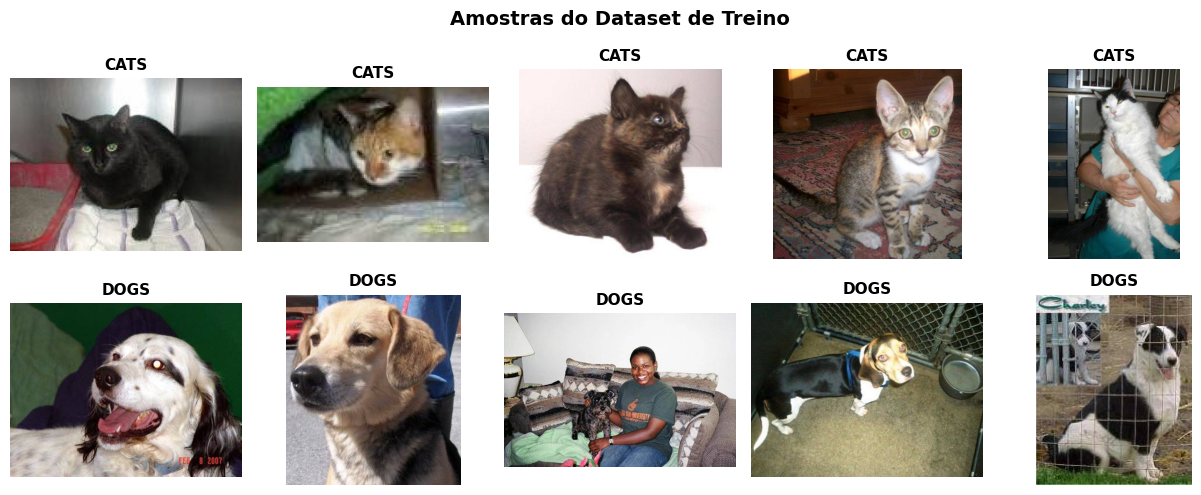

In [10]:
# Visualizar amostras do dataset de treino
def mostrar_amostras(diretorio, n_por_classe=5):

    classes = sorted([
        d for d in os.listdir(diretorio)
        if os.path.isdir(os.path.join(diretorio, d))
    ])

    fig, axes = plt.subplots(
        len(classes), n_por_classe,
        figsize=(n_por_classe * 2.5, len(classes) * 2.5)
    )

    fig.suptitle('Amostras do Dataset de Treino',
                 fontsize=14, fontweight='bold')

    for i, classe in enumerate(classes):
        pasta = os.path.join(diretorio, classe)

        arquivos = [
            f for f in os.listdir(pasta)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        escolhidos = random.sample(arquivos, n_por_classe)

        for j, arquivo in enumerate(escolhidos):

            img = Image.open(
                os.path.join(pasta, arquivo)
            ).convert('RGB')

            axes[i, j].imshow(img)
            axes[i, j].set_title(
                classe.upper(),
                fontsize=11,
                fontweight='bold'
            )
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()


mostrar_amostras(DIR_TRAIN)

---
## 4. 🔄 Pipeline de Augmentação de Dados

Com apenas ~700 imagens de treino, a **augmentação** é essencial. Ela cria variações artificiais das imagens originais, forçando o modelo a aprender características invariantes (posição, brilho, orientação).

**Estratégia:**
- Treino: augmentação moderada (crop, flip horizontal, rotação e variações de cor)
- Validação/Teste: apenas redimensionamento e normalização (sem aleatoriedade)

In [11]:
# ──────────────────────────────────────────────
# Hiperparâmetros globais
# ──────────────────────────────────────────────
IMG_SIZE   = 128
BATCH_SIZE = 32

# Normalização padrão ImageNet
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ──────────────────────────────────────────────
# TRAIN — com Data Augmentation
# ──────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((int(IMG_SIZE * 1.15), int(IMG_SIZE * 1.15))),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ──────────────────────────────────────────────
# VALIDATION / TEST / INFERENCE
# ──────────────────────────────────────────────
transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('✅ Pipelines de transformação definidos!')
print(f'   Imagem: {IMG_SIZE}x{IMG_SIZE}')
print(f'   Batch size: {BATCH_SIZE}')

✅ Pipelines de transformação definidos!
   Imagem: 128x128
   Batch size: 32


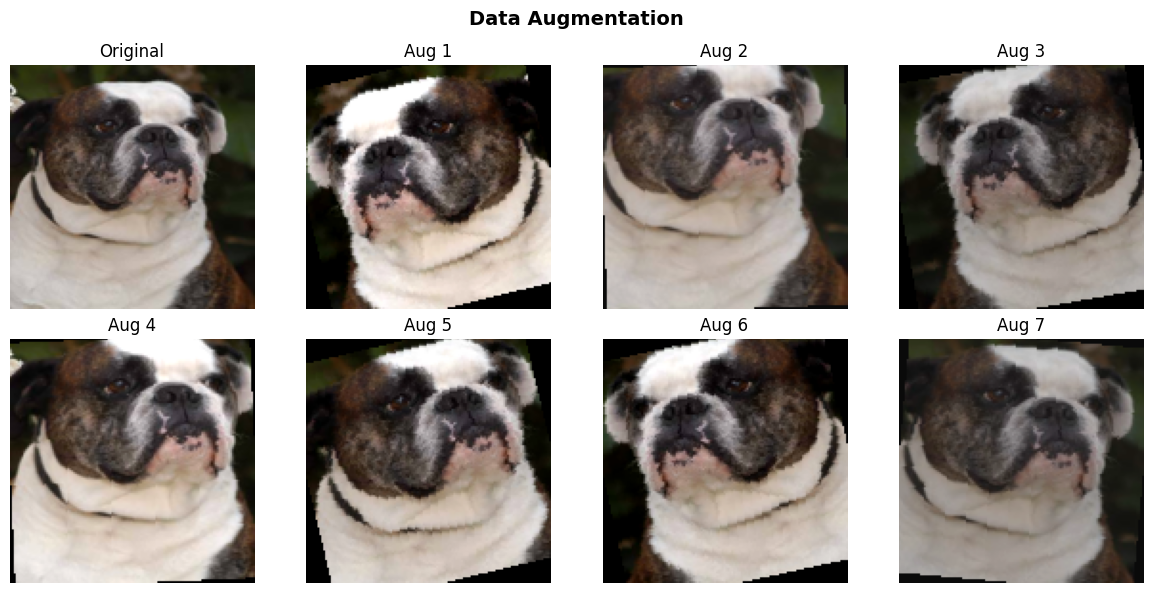

In [12]:
# Visualizar o efeito da augmentação
def visualizar_augmentacao(caminho_imagem, n=8):
    img = Image.open(caminho_imagem).convert('RGB')

    # Mesmas augmentações do treino, sem normalização
    aug_visual = transforms.Compose([
        transforms.Resize((int(IMG_SIZE * 1.15), int(IMG_SIZE * 1.15))),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2
        ),
    ])

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()

    # Original
    axes[0].imshow(img.resize((IMG_SIZE, IMG_SIZE)))
    axes[0].set_title('Original')
    axes[0].axis('off')

    # Imagens aumentadas
    for i in range(1, n):
        axes[i].imshow(aug_visual(img))
        axes[i].set_title(f'Aug {i}')
        axes[i].axis('off')

    plt.suptitle('Data Augmentation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Seleciona uma imagem do conjunto de treino
for root, _, files in os.walk(DIR_TRAIN):
    for f in files:
        if f.lower().endswith('.jpg'):
            visualizar_augmentacao(os.path.join(root, f))
            break
    else:
        continue
    break

---
## 5. 📦 Datasets e DataLoaders

In [13]:
# ──────────────────────────────────────────────
# Datasets
# ──────────────────────────────────────────────

ds_train = ImageFolder(DIR_TRAIN, transform=transform_train)

ds_validation = ImageFolder(
    DIR_VALIDATION,
    transform=transform_eval
)

ds_test = ImageFolder(
    DIR_TEST,
    transform=transform_eval
)

# ──────────────────────────────────────────────
# DataLoaders
# ──────────────────────────────────────────────

loader_train = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

loader_validation = DataLoader(
    ds_validation,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

loader_test = DataLoader(
    ds_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# Classes
classes = ds_train.classes

print(f'✅ Classes: {classes}')
print(f'   Train:      {len(ds_train)} imagens')
print(f'   Validation: {len(ds_validation)} imagens')
print(f'   Test:       {len(ds_test)} imagens')

✅ Classes: ['cats', 'dogs']
   Train:      699 imagens
   Validation: 150 imagens
   Test:       152 imagens


## 6. 🏗️ Arquitetura da CNN — Construída do Zero

### Por que uma CNN Residual?

À medida que uma CNN fica mais profunda, seu treinamento pode se tornar mais difícil. Os **blocos residuais (ResNet)** introduzem conexões de atalho (*skip connections*), permitindo que a informação e o gradiente atravessem a rede com maior facilidade.

A ideia central é simples: além de passar pelas camadas convolucionais, a entrada também possui um **caminho direto até a saída do bloco**.

```text
Entrada ──────────────────────────────┐
   │                                  │
   │                           skip connection
   ↓                                  │
 Conv → BN → ReLU → Conv → BN         │
   │                                  │
   └──────────────→ Soma ←────────────┘
                       │
                      ReLU

In [14]:
class BlocoResidual(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()

        self.bloco = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )

        self.projetor = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
            if stride != 1 or in_ch != out_ch
            else nn.Identity()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bloco(x) + self.projetor(x))


class CNNResidual(nn.Module):
    def __init__(self, n_classes=2, dropout=0.3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2, 1)
        )

        self.features = nn.Sequential(
            BlocoResidual(64, 64),
            BlocoResidual(64, 128, stride=2),
            BlocoResidual(128, 256, stride=2)
        )

        self.classificador = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        return self.classificador(x)

In [15]:
modelo = CNNResidual(
    n_classes=2,
    dropout=0.3
).to(device)

n_params = sum(
    p.numel()
    for p in modelo.parameters()
    if p.requires_grad
)

print(f'✅ CNN Residual criada do zero')
print(f'   Parâmetros treináveis: {n_params:,}')

✅ CNN Residual criada do zero
   Parâmetros treináveis: 1,233,218


---

## 7. 🏋️ Treinamento do Modelo

### Componentes do Pipeline de Treino

| Técnica | Por que usar |
|---|---|
| **AdamW** | Otimizador eficiente, com regularização por weight decay |
| **Label Smoothing** | Reduz excesso de confiança do modelo |
| **Gradient Clipping** | Ajuda a evitar gradientes muito altos |
| **Early Stopping** | Interrompe o treino quando a validação deixa de melhorar |
| **Mixed Precision (AMP)** | Acelera o treinamento quando há GPU compatível |

In [16]:
# ──────────────────────────────────────────────
# Hiperparâmetros de treinamento
# ──────────────────────────────────────────────
LR_INICIAL     = 3e-4
WEIGHT_DECAY   = 1e-4
NUM_EPOCHS     = 30
PACIENCIA_STOP = 7
CLIP_GRAD      = 1.0

# ──────────────────────────────────────────────
# Otimizador e função de perda
# ──────────────────────────────────────────────
otimizador = torch.optim.AdamW(
    modelo.parameters(),
    lr=LR_INICIAL,
    weight_decay=WEIGHT_DECAY
)

criterio = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# Mixed Precision — usada apenas quando houver GPU
#scaler = torch.cuda.amp.GradScaler(
#    enabled=(device.type == 'cuda')
#)

saidas = modelo(imagens)
loss = criterio(saidas, labels)

otimizador.zero_grad()
loss.backward()
otimizador.step()

print('✅ Treinamento configurado!')
print(f'   Épocas máximas: {NUM_EPOCHS}')
print(f'   Learning rate: {LR_INICIAL}')
print(f'   Early stopping: {PACIENCIA_STOP} épocas')

NameError: name 'imagens' is not defined

In [ ]:
# ──────────────────────────────────────────────
# Funções auxiliares de treino e avaliação
# ──────────────────────────────────────────────

def treinar_epoca(modelo, loader, otimizador, criterio, scaler, device, clip_grad):
    """Executa uma época de treinamento."""

    modelo.train()
    loss_total = 0.0
    corretos = 0
    total = 0

    for imagens, labels in loader:
        imagens = imagens.to(device)
        labels = labels.to(device)

        otimizador.zero_grad()

        # Forward com Mixed Precision
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            saidas = modelo(imagens)
            loss = criterio(saidas, labels)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.unscale_(otimizador)

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(
            modelo.parameters(),
            clip_grad
        )

        scaler.step(otimizador)
        scaler.update()

        loss_total += loss.item() * imagens.size(0)

        predicoes = saidas.argmax(dim=1)
        corretos += (predicoes == labels).sum().item()
        total += imagens.size(0)

    loss_media = loss_total / total
    acuracia = 100 * corretos / total

    return loss_media, acuracia


@torch.no_grad()
def avaliar(modelo, loader, criterio, device):
    """Avalia o modelo e retorna loss, acurácia, probabilidades e labels."""

    modelo.eval()

    loss_total = 0.0
    corretos = 0
    total = 0

    todas_probs = []
    todos_labels = []

    for imagens, labels in loader:
        imagens = imagens.to(device)
        labels = labels.to(device)

        saidas = modelo(imagens)
        loss = criterio(saidas, labels)

        probs = F.softmax(saidas, dim=1)
        predicoes = probs.argmax(dim=1)

        loss_total += loss.item() * imagens.size(0)
        corretos += (predicoes == labels).sum().item()
        total += imagens.size(0)

        todas_probs.append(probs.cpu())
        todos_labels.append(labels.cpu())

    loss_media = loss_total / total
    acuracia = 100 * corretos / total

    probs = torch.cat(todas_probs)
    labels = torch.cat(todos_labels)

    return loss_media, acuracia, probs, labels

In [ ]:
# ──────────────────────────────────────────────
# Loop de Treinamento Principal
# ──────────────────────────────────────────────

historico = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

melhor_val_loss = float('inf')
melhor_val_acc = 0.0
epocas_sem_melhora = 0

CAMINHO_CHECKPOINT = 'melhor_modelo.pth'

print('🚀 Iniciando treinamento...\n')
print(f'{"Época":>6} | {"T-Loss":>8} | {"T-Acc":>7} | {"V-Loss":>8} | {"V-Acc":>7}')
print('-' * 52)

for epoca in range(1, NUM_EPOCHS + 1):

    # Treino
    train_loss, train_acc = treinar_epoca(
        modelo,
        loader_train,
        otimizador,
        criterio,
        scaler,
        device,
        CLIP_GRAD
    )

    # Validação
    val_loss, val_acc, _, _ = avaliar(
        modelo,
        loader_validation,
        criterio,
        device
    )

    # Histórico
    historico['train_loss'].append(train_loss)
    historico['train_acc'].append(train_acc)
    historico['val_loss'].append(val_loss)
    historico['val_acc'].append(val_acc)

    # Salva o melhor modelo
    indicador = ''

    if val_loss < melhor_val_loss:
        melhor_val_loss = val_loss
        melhor_val_acc = val_acc
        epocas_sem_melhora = 0

        torch.save(
            modelo.state_dict(),
            CAMINHO_CHECKPOINT
        )

        indicador = '★'

    else:
        epocas_sem_melhora += 1

    print(
        f'{epoca:>6} | '
        f'{train_loss:>8.4f} | {train_acc:>6.2f}% | '
        f'{val_loss:>8.4f} | {val_acc:>6.2f}% {indicador}'
    )

    # Early Stopping
    if epocas_sem_melhora >= PACIENCIA_STOP:
        print(
            f'\n⏹️ Early stopping na época {epoca} '
            f'(sem melhora por {PACIENCIA_STOP} épocas)'
        )
        break


print('\n✅ Treinamento concluído!')
print(f'   Melhor Val Loss: {melhor_val_loss:.4f}')
print(f'   Melhor Val Acc:  {melhor_val_acc:.2f}%')

# Restaura o melhor modelo
modelo.load_state_dict(
    torch.load(CAMINHO_CHECKPOINT, map_location=device)
)

print('   Melhor checkpoint restaurado ✓')

---
## 8. 📊 Avaliação Completa

### 8.1 Curvas de Treinamento

In [ ]:
epocas = range(1, len(historico['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epocas, historico['train_loss'], label='Treino')
axes[0].plot(epocas, historico['val_loss'], label='Validação')

axes[0].set_title('Loss por Época', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Acurácia
axes[1].plot(epocas, historico['train_acc'], label='Treino')
axes[1].plot(epocas, historico['val_acc'], label='Validação')

axes[1].set_title('Acurácia por Época', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    'Histórico de Treinamento',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 8.2 Métricas Completas no Conjunto de Teste

> ⚠️ O conjunto de **teste** deve ser avaliado **uma única vez**, após todas as decisões de modelo e hiperparâmetros. Usá-lo durante o desenvolvimento cria _data leakage_.

In [ ]:
# Avaliação final no conjunto de teste
test_loss, test_acc, probs_test, labels_test = avaliar(
    modelo,
    loader_test,
    criterio,
    device
)

preds_test = probs_test.argmax(dim=1).numpy()
labels_np  = labels_test.numpy()

print('=' * 50)
print('📋 RELATÓRIO FINAL — CONJUNTO DE TESTE')
print('=' * 50)

print(f'Loss     : {test_loss:.4f}')
print(f'Acurácia : {test_acc:.2f}%')
print()

print(
    classification_report(
        labels_np,
        preds_test,
        target_names=classes
    )
)

### 8.3 Matriz de Confusão e Curva ROC

In [ ]:
# Probabilidade da classe positiva (dogs = 1)
probs_pos = probs_test[:, 1].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Matriz de Confusão ──────────────────────────
cm = confusion_matrix(labels_np, preds_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)

axes[0].set_title('Matriz de Confusão', fontweight='bold')


# ── Curva ROC ───────────────────────────────────
fpr, tpr, _ = roc_curve(labels_np, probs_pos)
area = auc(fpr, tpr)

axes[1].plot(
    fpr, tpr,
    lw=2,
    label=f'AUC = {area:.3f}'
)

axes[1].plot(
    [0, 1], [0, 1],
    '--',
    label='Aleatório (AUC = 0.5)'
)

axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    'Desempenho no Conjunto de Teste',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print(f'🏆 AUC-ROC: {area:.4f}')

### 8.4 Análise de Erros — Imagens Classificadas Incorretamente

Analisar os erros é fundamental em projetos reais para identificar padrões problemáticos (ex: gatos brancos confundidos com cães brancos).

In [ ]:
def mostrar_erros(modelo, loader, classes, device, n_mostrar=12):
    """Exibe imagens classificadas incorretamente pelo modelo."""

    modelo.eval()

    erros_imgs = []
    erros_labels = []
    erros_preds = []
    erros_conf = []

    # Valores usados para desnormalizar as imagens
    mean_t = torch.tensor(MEAN).view(3, 1, 1)
    std_t = torch.tensor(STD).view(3, 1, 1)

    with torch.no_grad():

        for imagens, labels in loader:

            imagens_device = imagens.to(device)

            saidas = modelo(imagens_device)
            probs = F.softmax(saidas, dim=1).cpu()
            predicoes = probs.argmax(dim=1)

            erros = predicoes != labels

            for i in erros.nonzero(as_tuple=True)[0]:

                # Desnormaliza a imagem para visualização
                img = imagens[i] * std_t + mean_t
                img = img.permute(1, 2, 0).clamp(0, 1).numpy()

                erros_imgs.append(img)
                erros_labels.append(labels[i].item())
                erros_preds.append(predicoes[i].item())
                erros_conf.append(
                    probs[i, predicoes[i]].item()
                )

    n = min(n_mostrar, len(erros_imgs))

    print(f'❌ Total de erros no conjunto de teste: {len(erros_imgs)}')

    if n == 0:
        print('✅ Nenhum erro para mostrar!')
        return

    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * 3, rows * 3)
    )

    axes = np.array(axes).reshape(-1)

    for i in range(n):

        axes[i].imshow(erros_imgs[i])

        verdadeiro = classes[erros_labels[i]]
        previsto = classes[erros_preds[i]]

        axes[i].set_title(
            f'Real: {verdadeiro}\n'
            f'Previsto: {previsto} ({erros_conf[i]:.0%})',
            fontsize=9
        )

        axes[i].axis('off')

    # Oculta espaços não utilizados
    for i in range(n, len(axes)):
        axes[i].axis('off')

    plt.suptitle(
        'Imagens Classificadas Incorretamente',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


mostrar_erros(
    modelo,
    loader_test,
    classes,
    device
)

### 8.5 Interpretabilidade — GradCAM (Conteúdo Complementar)

O GradCAM permite visualizar quais regiões da imagem mais influenciaram
a decisão da CNN.

Nesta disciplina, o objetivo é compreender e interpretar o resultado
gerado pelo GradCAM, sem a necessidade de aprofundar os detalhes de
implementação do algoritmo.

In [ ]:
class GradCAM:
    """
    Implementação simples do GradCAM.
    """

    def __init__(self, modelo, camada_alvo):
        self.modelo = modelo
        self.gradientes = None
        self.ativacoes = None

        camada_alvo.register_forward_hook(
            self._hook_ativacao
        )

        camada_alvo.register_full_backward_hook(
            self._hook_gradiente
        )

    def _hook_ativacao(self, module, input, output):
        self.ativacoes = output.detach()

    def _hook_gradiente(self, module, grad_input, grad_output):
        self.gradientes = grad_output[0].detach()

    def gerar(self, img_tensor, classe_idx=None):

        self.modelo.eval()

        saidas = self.modelo(img_tensor)

        if classe_idx is None:
            classe_idx = saidas.argmax(dim=1).item()

        self.modelo.zero_grad()

        saidas[0, classe_idx].backward()

        # Média dos gradientes por canal
        pesos = self.gradientes.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Combina pesos e ativações
        cam = (pesos * self.ativacoes).sum(dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze()

        # Normalização entre 0 e 1
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy(), classe_idx

---
## 9. 🔮 Inferência em Imagens Novas

Esta seção simula o uso do modelo em produção: uma função que recebe qualquer imagem e retorna a predição com confiança.

In [ ]:
def classificar_imagem(caminho_ou_url, modelo, classes, device, mostrar=True):
    """
    Classifica uma imagem como gato ou cachorro.
    """

    # Carrega imagem local ou por URL
    if caminho_ou_url.startswith('http'):
        import requests
        from io import BytesIO

        resposta = requests.get(caminho_ou_url, timeout=10)
        resposta.raise_for_status()

        img = Image.open(
            BytesIO(resposta.content)
        ).convert('RGB')

    else:
        img = Image.open(
            caminho_ou_url
        ).convert('RGB')


    # Pré-processamento
    tensor = transform_eval(img).unsqueeze(0).to(device)


    # Inferência
    modelo.eval()

    with torch.no_grad():
        saidas = modelo(tensor)
        probs = F.softmax(saidas, dim=1).squeeze().cpu()


    idx_pred = probs.argmax().item()

    classe_pred = classes[idx_pred]
    confianca = probs[idx_pred].item()


    # Exibe resultado
    if mostrar:

        emoji = '🐱' if classe_pred == 'cats' else '🐶'

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')

        plt.title(
            f'{emoji} {classe_pred.upper()}\n'
            f'Confiança: {confianca:.1%}',
            fontsize=13,
            fontweight='bold'
        )

        plt.show()


    return {
        'classe': classe_pred,
        'confianca': confianca,
        'probabilidades': {
            classe: probs[i].item()
            for i, classe in enumerate(classes)
        }
    }

In [ ]:
print('🔎 Exemplos com imagens do conjunto de teste:\n')

for classe in classes:

    pasta = os.path.join(
        DIR_TEST,
        classe
    )

    arquivos = [
        f for f in os.listdir(pasta)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    if arquivos:

        caminho = os.path.join(
            pasta,
            arquivos[0]
        )

        resultado = classificar_imagem(
            caminho,
            modelo,
            classes,
            device
        )

        print(f'Real     : {classe}')
        print(f'Previsto : {resultado["classe"]}')
        print(f'Confiança: {resultado["confianca"]:.2%}')
        print()

In [ ]:
print('🔮 Inferência em imagens novas:\n')

arquivos = [
    f for f in os.listdir(DIR_INFERENCE)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

for arquivo in arquivos[:5]:

    caminho = os.path.join(
        DIR_INFERENCE,
        arquivo
    )

    resultado = classificar_imagem(
        caminho,
        modelo,
        classes,
        device
    )

    print(
        f'{arquivo} → '
        f'{resultado["classe"]} '
        f'({resultado["confianca"]:.1%})'
    )

---
## 10. 💾 Exportação do Modelo

Em produção, é comum exportar o modelo para formatos mais eficientes de servir.

In [ ]:
!pip install -q onnx onnxscript

In [ ]:
CAMINHO_ONNX = "/content/classificador_cats_dogs.onnx"

# Exemplo de entrada com o mesmo tamanho usado pela CNN
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

modelo.eval()

torch.onnx.export(
    modelo,
    dummy_input,
    CAMINHO_ONNX,
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    external_data=False
)

print(f"✅ Modelo ONNX exportado: {CAMINHO_ONNX}")

---

## 📝 Resumo Final

### Resultados

| Métrica | Valor |
|---|---:|
| Melhor Val Loss | 0.6327 |
| Melhor Val Acc | 71.64% |
| Teste Acc | 62.00% |
| AUC-ROC | 0.6831 |

> 💡 Os resultados podem variar a cada treinamento devido à inicialização dos pesos e às transformações aleatórias aplicadas às imagens.

---

### Lições de Engenharia Aplicadas

1. **Limpeza dos dados** — verificação de imagens corrompidas e duplicadas antes do treinamento.

2. **Data Augmentation** — criação dinâmica de variações das imagens de treino para melhorar a capacidade de generalização.

3. **CNN Residual** — uso de *skip connections* para facilitar o fluxo de informação e o treinamento da rede.

4. **Regularização** — combinação de BatchNorm, Dropout, Weight Decay e Label Smoothing para reduzir overfitting.

5. **Gradient Clipping** — controle de gradientes muito altos durante o treinamento.

6. **Early Stopping** — interrupção do treinamento quando a validação deixa de melhorar.

7. **Avaliação independente** — separação dos dados em treino, validação e teste, mantendo o teste para a avaliação final.

8. **Análise de desempenho** — uso de acurácia, Precision, Recall, F1-score, matriz de confusão e AUC-ROC.

9. **Interpretabilidade** — uso do GradCAM para visualizar regiões da imagem relevantes para as decisões da CNN.

10. **Inferência e exportação** — classificação de novas imagens e exportação do modelo nos formatos PyTorch (.pth) e ONNX (.onnx).

---

### 🎯 Pipeline Completo

**Dados → Limpeza → Augmentation → CNN Residual → Treinamento → Validação → Teste → GradCAM → Inferência → Exportação**

O projeto percorreu o ciclo completo de desenvolvimento de um modelo de Visão Computacional, desde a preparação dos dados até a geração de um modelo treinado e reutilizável em futuras aplicações.

Se você chegou até aqui - Parabéns!